<a href="https://colab.research.google.com/github/khanhngoo/DataVisualization_Project1_Team_23and4/blob/main/Project1_DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# STEP 1: END-TO-END DATA PIPELINE
# ==========================================
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
df = pd.read_csv(url)

# 1. Type Casting
cat_cols = ['species', 'island', 'sex']
for col in cat_cols:
    df[col] = df[col].astype('category')

# 2. Missing Value Imputation
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[['sex']] = cat_imputer.fit_transform(df[['sex']])

# 3. Filtering
# Defensive check to drop any structurally corrupted rows (e.g., negative body mass)
df = df[df['body_mass_g'] > 0]

# 4. Aggregation
# Creating a clean summary table for the dashboard to use for high-level KPIs
agg_summary_df = df.groupby(['species', 'island'], observed=True)[num_cols].mean().reset_index()


# ==========================================
# STEP 2: MACHINE LEARNING PIPELINE
# ==========================================

# Standardization (Critical for PCA and K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[num_cols])

# PCA (Dimensionality Reduction to 2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
df['PCA_X'] = pca_result[:, 0]
df['PCA_Y'] = pca_result[:, 1]

# K-Means Clustering (Unsupervised grouping, k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Displaying the first few rows to verify the pipeline succeeded
print("Pipeline Executed Successfully! Here is the aggregated summary:")
print(agg_summary_df.head())



Pipeline Executed Successfully! Here is the aggregated summary:
     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0     Adelie     Biscoe       38.975000      18.370455         188.795455   
1     Adelie      Dream       38.501786      18.251786         189.732143   
2     Adelie  Torgersen       39.056731      18.407692         191.307692   
3  Chinstrap      Dream       48.833824      18.420588         195.823529   
4     Gentoo     Biscoe       47.480242      15.000806         217.024194   

   body_mass_g  
0  3709.659091  
1  3688.392857  
2  3712.980769  
3  3733.088235  
4  5067.741935  


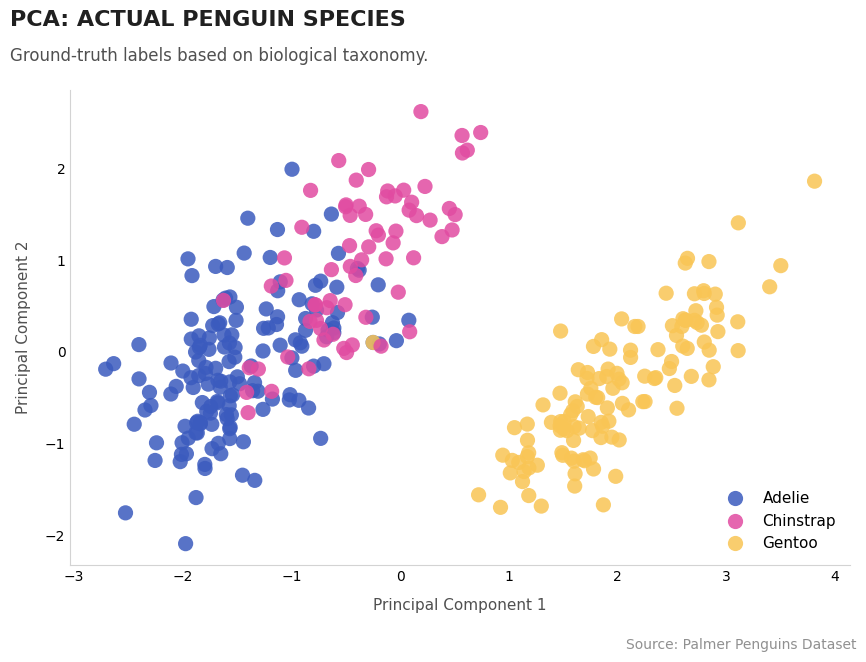

In [2]:
# ==========================================
# VISUALIZATION SETUP
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
species_palette = {'Adelie': '#3B5BBE', 'Chinstrap': '#E14BA1', 'Gentoo': '#F9C555'}
kmeans_palette = {0: '#00A8E8',  # Bright Cyan
                  1: '#D90429',  # Crimson Red
                  2: '#8338EC'}  # Vivid Purple

def style_axes(ax):
    """Helper function to apply OHA styling to an axis"""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D3D3D3')
    ax.spines['bottom'].set_color('#D3D3D3')
    ax.tick_params(axis='both', which='both', length=0, labelsize=10)
    ax.set_xlabel('Principal Component 1', color='#505050', fontsize=11, labelpad=10)
    ax.set_ylabel('Principal Component 2', color='#505050', fontsize=11, labelpad=10)

# ==========================================
# PLOT A: GROUND TRUTH
# ==========================================
fig_a, ax_a = plt.subplots(figsize=(9, 7))
fig_a.patch.set_facecolor('white')

sns.scatterplot(
    data=df, x='PCA_X', y='PCA_Y',
    hue='species', palette=species_palette,
    s=120, ax=ax_a, alpha=0.85, edgecolor='none'
)

fig_a.text(0.03, 0.92, 'PCA: ACTUAL PENGUIN SPECIES',
         fontsize=16, fontweight='bold', color='#202020', ha='left')
fig_a.text(0.03, 0.87, 'Ground-truth labels based on biological taxonomy.',
         fontsize=12, color='#505050', ha='left')

style_axes(ax_a)
ax_a.legend(frameon=False, loc='lower right', title='', fontsize=11)
fig_a.text(0.97, 0.03, 'Source: Palmer Penguins Dataset', ha='right', fontsize=10, color='#909090')

plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.85])
plt.savefig('Plot_A_Ground_Truth.png', dpi=300, bbox_inches='tight')
plt.show()



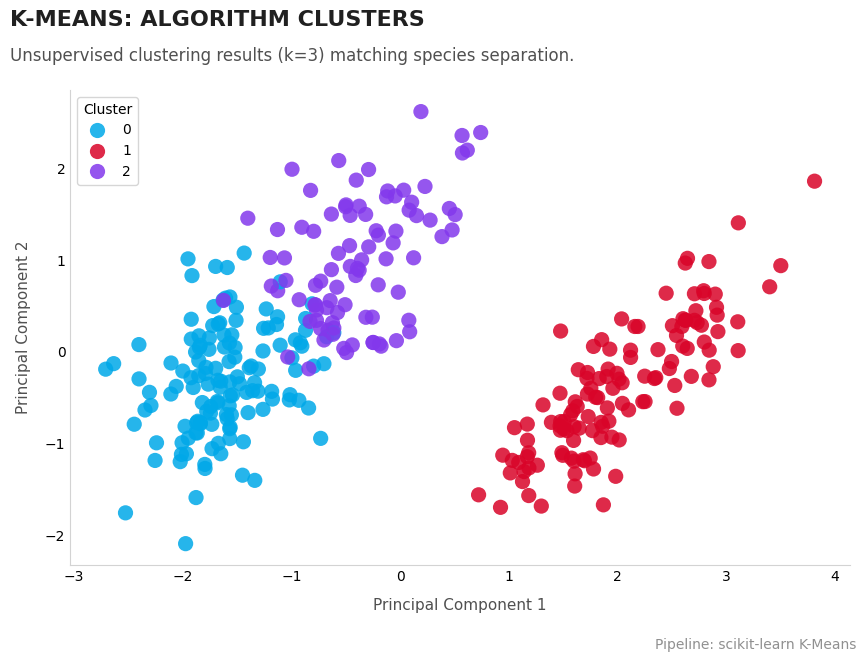

In [3]:
# ==========================================
# PLOT B: K-MEANS ALGORITHM
# ==========================================
fig_b, ax_b = plt.subplots(figsize=(9, 7))
fig_b.patch.set_facecolor('white')

sns.scatterplot(
    data=df, x='PCA_X', y='PCA_Y',
    hue='Cluster', palette=kmeans_palette,
    s=120, ax=ax_b, alpha=0.85, edgecolor='none', legend='full'
)

fig_b.text(0.03, 0.92, 'K-MEANS: ALGORITHM CLUSTERS',
         fontsize=16, fontweight='bold', color='#202020', ha='left')
fig_b.text(0.03, 0.87, 'Unsupervised clustering results (k=3) matching species separation.',
         fontsize=12, color='#505050', ha='left')

style_axes(ax_b)
fig_b.text(0.97, 0.03, 'Pipeline: scikit-learn K-Means', ha='right', fontsize=10, color='#909090')

plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.85])
plt.savefig('Plot_B_KMeans.png', dpi=300, bbox_inches='tight')
plt.show()